Weight Initlizations Rules
*   Things not to do
    1.   0 intilizations(no training)
    2.   non zero constant intialzations(becomes a linear model)
    3.   random intialzations with small weights(vanishing gradient and slow convergence)
    4.   random intialzations with large weights(vanishing gradient and exploting gradient)

*   Things to do (heuristics approach for weight intialization)
    1.   xavier/glorat intilazation(normal and uniform)
      *   xavier works best for tanh and sigmoid
    2.   he intilzation(normal and uniform)
        *   he works best for ReLU
  

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [5]:
df = pd.read_csv('/content/ushape1.csv')

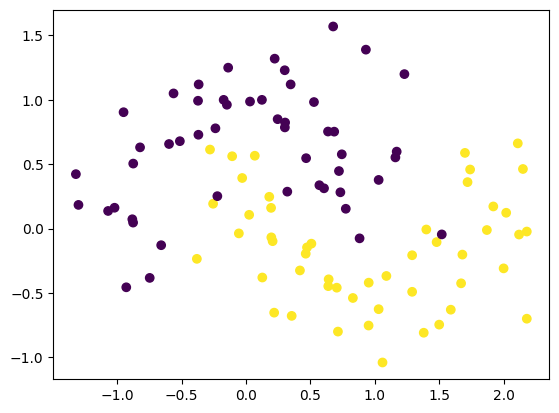

In [6]:
plt.scatter(df["X"], df["Y"], c=df["Class"])

In [7]:
x, y = df.iloc[:, 0:2].values, df.iloc[:, 2].values

In [23]:
model = Sequential()
model.add(Dense(10, input_dim=2, activation='relu', kernel_initializer="glorot_normal"))
model.add(Dense(10, activation='relu', kernel_initializer="glorot_normal"))
model.add(Dense(10, activation='relu', kernel_initializer="glorot_normal"))
model.add(Dense(10, activation='relu', kernel_initializer="glorot_normal"))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [26]:
history = model.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.5312 - loss: 0.6867 - val_accuracy: 0.5000 - val_loss: 0.6721
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4688 - loss: 0.6891 - val_accuracy: 0.5000 - val_loss: 0.6678
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4844 - loss: 0.6850 - val_accuracy: 0.5000 - val_loss: 0.6635
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5117 - loss: 0.6775 - val_accuracy: 0.5000 - val_loss: 0.6594
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4609 - loss: 0.6796 - val_accuracy: 0.5000 - val_loss: 0.6554
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4883 - loss: 0.6754 - val_accuracy: 0.5000 - val_loss: 0.6515
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5117 - loss: 0.6732 - val_accuracy: 0.5000 - val_loss: 0.6475
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4805 - loss: 0.6725 - val_accuracy: 0.5000 - val_loss

Glorot Normal - ReLU

  45/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step   

<ipython-input-27-5116975b4946>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

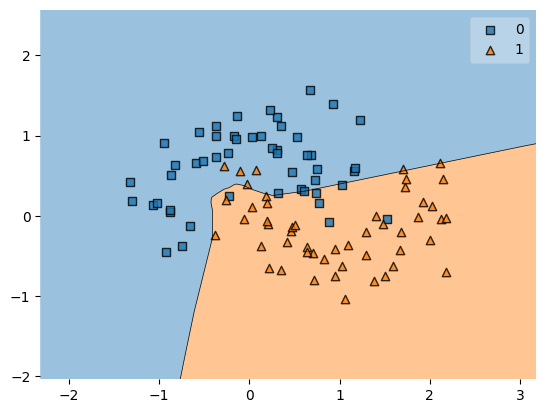

In [27]:
plot_decision_regions(x, y.astype(np.integer), clf=model)

In [28]:
model1 = Sequential()
model1.add(Dense(10, input_dim=2, activation='tanh', kernel_initializer="glorot_normal"))
model1.add(Dense(10, activation='tanh', kernel_initializer="glorot_normal"))
model1.add(Dense(10, activation='tanh', kernel_initializer="glorot_normal"))
model1.add(Dense(10, activation='tanh', kernel_initializer="glorot_normal"))
model1.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [32]:
history1 = model1.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.6961 - loss: 0.6416 - val_accuracy: 0.8500 - val_loss: 0.5894
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7117 - loss: 0.6295 - val_accuracy: 0.8500 - val_loss: 0.5764
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7312 - loss: 0.6085 - val_accuracy: 0.8500 - val_loss: 0.5644
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7164 - loss: 0.6086 - val_accuracy: 0.8500 - val_loss: 0.5531
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7828 - loss: 0.5810 - val_accuracy: 0.8500 - val_loss: 0.5420
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7797 - loss: 0.5830 - val_accuracy: 0.8500 - val_loss: 0.5315
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7875 - loss: 0.5669 - val_accuracy: 0.8500 - val_loss: 0.5212
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7602 - loss: 0.5711 - val_accuracy: 0.8500 - val_loss

Glorot Normal - TanH

   1/9600 ━━━━━━━━━━━━━━━━━━━━ 15:55 100ms/step

<ipython-input-33-97ec1e121ad1>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model1)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

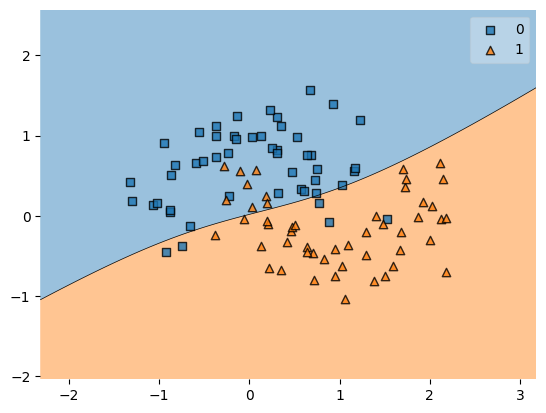

In [33]:
plot_decision_regions(x, y.astype(np.integer), clf=model1)

In [34]:
model2 = Sequential()
model2.add(Dense(10, input_dim=2, activation='sigmoid', kernel_initializer="glorot_normal"))
model2.add(Dense(10, activation='sigmoid', kernel_initializer="glorot_normal"))
model2.add(Dense(10, activation='sigmoid', kernel_initializer="glorot_normal"))
model2.add(Dense(10, activation='sigmoid', kernel_initializer="glorot_normal"))
model2.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [37]:
history2 = model2.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.4922 - loss: 0.7457 - val_accuracy: 0.5000 - val_loss: 0.7370
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4805 - loss: 0.7483 - val_accuracy: 0.5000 - val_loss: 0.7331
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5078 - loss: 0.7282 - val_accuracy: 0.5000 - val_loss: 0.7296
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5078 - loss: 0.7249 - val_accuracy: 0.5000 - val_loss: 0.7261
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4844 - loss: 0.7341 - val_accuracy: 0.5000 - val_loss: 0.7227
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5312 - loss: 0.7068 - val_accuracy: 0.5000 - val_loss: 0.7196
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4727 - loss: 0.7324 - val_accuracy: 0.5000 - val_loss: 0.7166
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4961 - loss: 0.7181 - val_accuracy: 0.5000 - val_loss

Glorot Normal - Sigmoid

  40/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step   

<ipython-input-38-4da1a2961f74>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model2)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

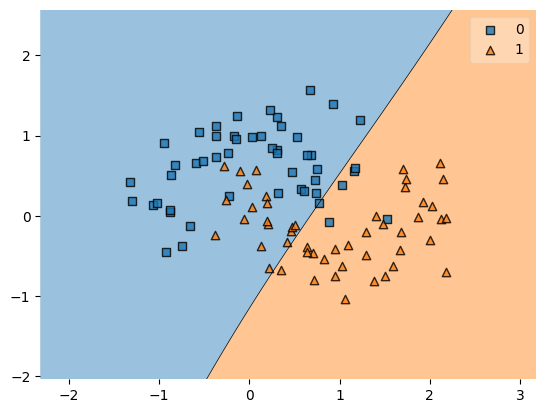

In [38]:
plot_decision_regions(x, y.astype(np.integer), clf=model2)

**Glorot Normal is bset for TanH**

In [39]:
model3 = Sequential()
model3.add(Dense(10, input_dim=2, activation='relu', kernel_initializer="glorot_uniform"))
model3.add(Dense(10, activation='relu', kernel_initializer="glorot_uniform"))
model3.add(Dense(10, activation='relu', kernel_initializer="glorot_uniform"))
model3.add(Dense(10, activation='relu', kernel_initializer="glorot_uniform"))
model3.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model3.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [42]:
history3 = model3.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.7961 - loss: 0.6850 - val_accuracy: 0.8500 - val_loss: 0.6825
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7844 - loss: 0.6822 - val_accuracy: 0.9000 - val_loss: 0.6796
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8383 - loss: 0.6789 - val_accuracy: 0.9500 - val_loss: 0.6767
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8430 - loss: 0.6760 - val_accuracy: 0.9500 - val_loss: 0.6738
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8586 - loss: 0.6739 - val_accuracy: 0.9500 - val_loss: 0.6708
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8406 - loss: 0.6714 - val_accuracy: 0.9000 - val_loss: 0.6677
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8445 - loss: 0.6669 - val_accuracy: 0.9500 - val_loss: 0.6643
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8562 - loss: 0.6615 - val_accuracy: 0.9000 - val_loss

Glorot Uniform - ReLU

   1/9600 ━━━━━━━━━━━━━━━━━━━━ 12:02 75ms/step

<ipython-input-43-655aa3d4ba41>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model3)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

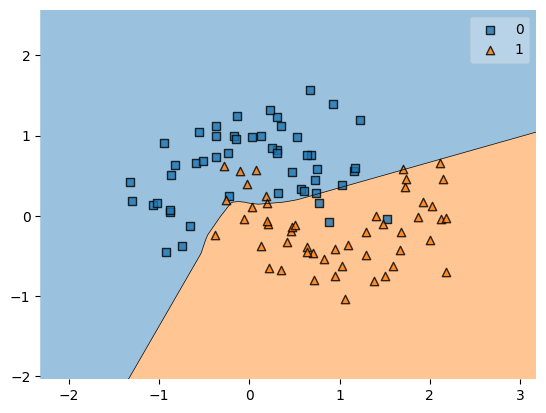

In [43]:
plot_decision_regions(x, y.astype(np.integer), clf=model3)

In [44]:
model4 = Sequential()
model4.add(Dense(10, input_dim=2, activation='tanh', kernel_initializer="glorot_uniform"))
model4.add(Dense(10, activation='tanh', kernel_initializer="glorot_uniform"))
model4.add(Dense(10, activation='tanh', kernel_initializer="glorot_uniform"))
model4.add(Dense(10, activation='tanh', kernel_initializer="glorot_uniform"))
model4.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
model4.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model4.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [47]:
history4 = model4.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.5695 - loss: 0.6806 - val_accuracy: 0.7500 - val_loss: 0.5934
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6242 - loss: 0.6532 - val_accuracy: 0.7500 - val_loss: 0.5786
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5953 - loss: 0.6502 - val_accuracy: 0.8000 - val_loss: 0.5660
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5930 - loss: 0.6340 - val_accuracy: 0.8000 - val_loss: 0.5540
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5977 - loss: 0.6316 - val_accuracy: 0.8000 - val_loss: 0.5427
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6469 - loss: 0.6023 - val_accuracy: 0.8500 - val_loss: 0.5312
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6398 - loss: 0.6028 - val_accuracy: 0.8500 - val_loss: 0.5210
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6773 - loss: 0.5846 - val_accuracy: 0.8000 - val_loss

Glorot Uniform - TanH

  39/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step   

<ipython-input-48-acad445bdf43>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model4)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

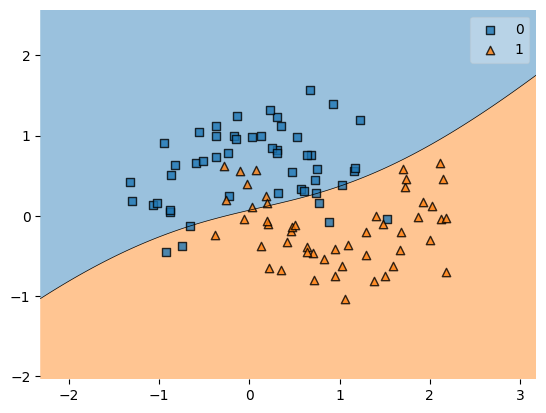

In [48]:
plot_decision_regions(x, y.astype(np.integer), clf=model4)

In [49]:
model5 = Sequential()
model5.add(Dense(10, input_dim=2, activation='sigmoid', kernel_initializer="glorot_uniform"))
model5.add(Dense(10, activation='sigmoid', kernel_initializer="glorot_uniform"))
model5.add(Dense(10, activation='sigmoid', kernel_initializer="glorot_uniform"))
model5.add(Dense(10, activation='sigmoid', kernel_initializer="glorot_uniform"))
model5.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model5.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model5.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [52]:
history5 = model5.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.5078 - loss: 0.8714 - val_accuracy: 0.5000 - val_loss: 0.8729
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5352 - loss: 0.8272 - val_accuracy: 0.5000 - val_loss: 0.8630
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4961 - loss: 0.8658 - val_accuracy: 0.5000 - val_loss: 0.8534
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4883 - loss: 0.8655 - val_accuracy: 0.5000 - val_loss: 0.8444
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5156 - loss: 0.8250 - val_accuracy: 0.5000 - val_loss: 0.8356
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4648 - loss: 0.8728 - val_accuracy: 0.5000 - val_loss: 0.8269
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5078 - loss: 0.8169 - val_accuracy: 0.5000 - val_loss: 0.8186
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4688 - loss: 0.8494 - val_accuracy: 0.5000 - val_loss

Glorot Uniform - Sigmoid

<ipython-input-53-e465dea5bf9b>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model5)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

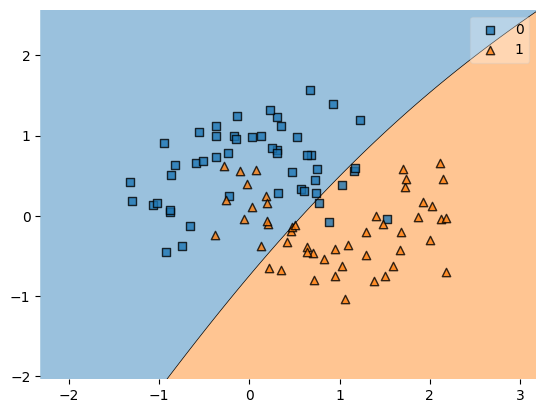

In [53]:
plot_decision_regions(x, y.astype(np.integer), clf=model5)

**Glorot Uniform - ReLU is best**

In [54]:
model6 = Sequential()
model6.add(Dense(10, input_dim=2, activation='relu', kernel_initializer="he_normal"))
model6.add(Dense(10, activation='relu', kernel_initializer="he_normal"))
model6.add(Dense(10, activation='relu', kernel_initializer="he_normal"))
model6.add(Dense(10, activation='relu', kernel_initializer="he_normal"))
model6.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model6.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
model6.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [57]:
history6 = model6.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.4805 - loss: 1.4942 - val_accuracy: 0.5000 - val_loss: 1.3005
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5078 - loss: 1.2876 - val_accuracy: 0.5000 - val_loss: 1.2458
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5078 - loss: 1.3050 - val_accuracy: 0.5000 - val_loss: 1.1930
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 1.2423 - val_accuracy: 0.5000 - val_loss: 1.1430
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5234 - loss: 1.1121 - val_accuracy: 0.5000 - val_loss: 1.0968
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4398 - loss: 1.2547 - val_accuracy: 0.5500 - val_loss: 1.0525
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5219 - loss: 1.1009 - val_accuracy: 0.5500 - val_loss: 1.0117
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5203 - loss: 1.1333 - val_accuracy: 0.6000 - val_los

He_normal - ReLU

  33/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step   

<ipython-input-58-3b148ca8bc70>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model6)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

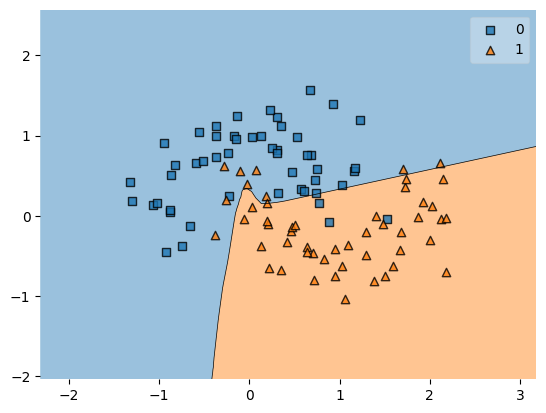

In [58]:
plot_decision_regions(x, y.astype(np.integer), clf=model6)

In [59]:
model7 = Sequential()
model7.add(Dense(10, input_dim=2, activation='tanh', kernel_initializer="he_normal"))
model7.add(Dense(10, activation='tanh', kernel_initializer="he_normal"))
model7.add(Dense(10, activation='tanh', kernel_initializer="he_normal"))
model7.add(Dense(10, activation='tanh', kernel_initializer="he_normal"))
model7.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model7.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model7.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [62]:
history7 = model7.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - accuracy: 0.3945 - loss: 1.0212 - val_accuracy: 0.3000 - val_loss: 1.0765
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4789 - loss: 0.8806 - val_accuracy: 0.3000 - val_loss: 0.9814
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5156 - loss: 0.8075 - val_accuracy: 0.3000 - val_loss: 0.8928
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5164 - loss: 0.7520 - val_accuracy: 0.3500 - val_loss: 0.8122
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6383 - loss: 0.6911 - val_accuracy: 0.4500 - val_loss: 0.7405
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6445 - loss: 0.6509 - val_accuracy: 0.6000 - val_loss: 0.6783
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6195 - loss: 0.6394 - val_accuracy: 0.6000 - val_loss: 0.6257
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6797 - loss: 0.6025 - val_accuracy: 0.6500 - val_loss

He_Normal - TanH

   1/9600 ━━━━━━━━━━━━━━━━━━━━ 17:34 110ms/step

<ipython-input-63-3430e56f272b>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model7)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

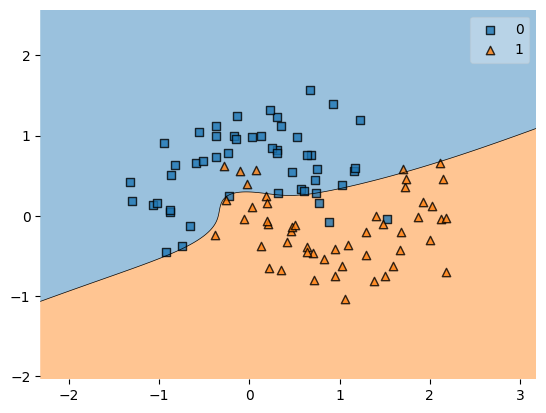

In [63]:
plot_decision_regions(x, y.astype(np.integer), clf=model7)

In [64]:
model8 = Sequential()
model8.add(Dense(10, input_dim=2, activation='sigmoid', kernel_initializer="he_normal"))
model8.add(Dense(10, activation='sigmoid', kernel_initializer="he_normal"))
model8.add(Dense(10, activation='sigmoid', kernel_initializer="he_normal"))
model8.add(Dense(10, activation='sigmoid', kernel_initializer="he_normal"))
model8.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
model8.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_49 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model8.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [67]:
history8  = model8.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.4961 - loss: 0.7170 - val_accuracy: 0.5000 - val_loss: 0.7120
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5078 - loss: 0.7083 - val_accuracy: 0.5000 - val_loss: 0.7086
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.7082 - val_accuracy: 0.5000 - val_loss: 0.7055
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4766 - loss: 0.7131 - val_accuracy: 0.5000 - val_loss: 0.7030
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5195 - loss: 0.6969 - val_accuracy: 0.5000 - val_loss: 0.7012
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4727 - loss: 0.7085 - val_accuracy: 0.5000 - val_loss: 0.6998
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5273 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6988
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.4922 - loss: 0.7006 - val_accuracy: 0.5000 - val_lo

He_Normal - Sigmoid

  31/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step   

<ipython-input-68-5d465e54dee8>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model8)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: >

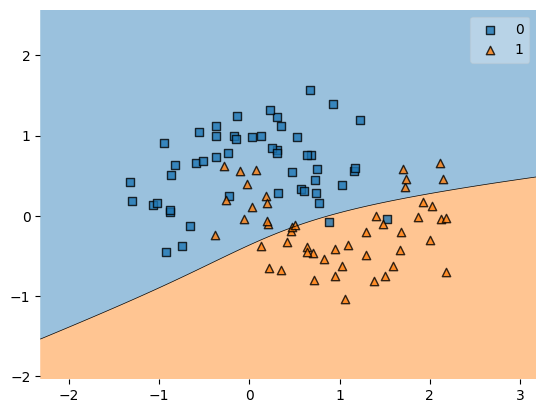

In [68]:
plot_decision_regions(x, y.astype(np.integer), clf=model8)

**He_Normal - ReLU is best**

In [69]:
model9 = Sequential()
model9.add(Dense(10, activation='relu', input_dim=2, kernel_initializer="he_uniform"))
model9.add(Dense(10, activation='relu', kernel_initializer="he_uniform"))
model9.add(Dense(10, activation='relu', kernel_initializer="he_uniform"))
model9.add(Dense(10, activation='relu', kernel_initializer="he_uniform"))
model9.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
model9.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_55 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_56 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_57 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_58 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
model9.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [72]:
history9 = model9.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.4750 - loss: 0.6144 - val_accuracy: 0.7000 - val_loss: 0.4983
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5602 - loss: 0.5939 - val_accuracy: 0.7000 - val_loss: 0.4877
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6320 - loss: 0.5727 - val_accuracy: 0.7500 - val_loss: 0.4780
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6242 - loss: 0.5766 - val_accuracy: 0.7500 - val_loss: 0.4700
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5852 - loss: 0.5711 - val_accuracy: 0.7500 - val_loss: 0.4623
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6391 - loss: 0.5818 - val_accuracy: 0.8000 - val_loss: 0.4552
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6438 - loss: 0.5751 - val_accuracy: 0.8000 - val_loss: 0.4482
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7133 - loss: 0.5331 - val_accuracy: 0.8500 - val_loss

He_Uniform - ReLU

   1/9600 ━━━━━━━━━━━━━━━━━━━━ 14:22 90ms/step

<ipython-input-73-ffd6c21736f8>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model9)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: >

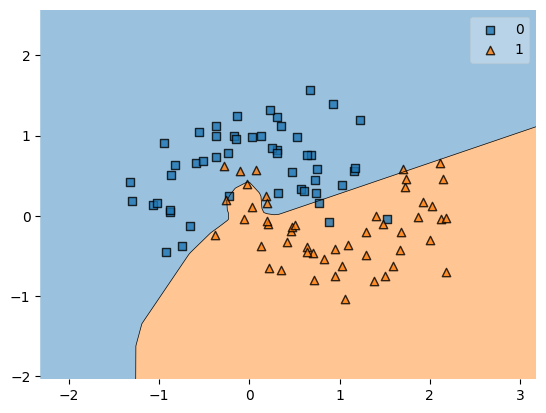

In [73]:
plot_decision_regions(x, y.astype(np.integer), clf=model9)

In [74]:
model10 = Sequential()
model10.add(Dense(10, activation='tanh', input_dim=2, kernel_initializer="he_uniform"))
model10.add(Dense(10, activation='tanh', kernel_initializer="he_uniform"))
model10.add(Dense(10, activation='tanh', kernel_initializer="he_uniform"))
model10.add(Dense(10, activation='tanh', kernel_initializer="he_uniform"))
model10.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
model10.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_59 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_60 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_61 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_62 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
model10.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [77]:
history10 = model10.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.6500 - loss: 0.6180 - val_accuracy: 0.8000 - val_loss: 0.5387
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7016 - loss: 0.5986 - val_accuracy: 0.8000 - val_loss: 0.5253
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7258 - loss: 0.5849 - val_accuracy: 0.8500 - val_loss: 0.5126
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7719 - loss: 0.5752 - val_accuracy: 0.8500 - val_loss: 0.4989
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7602 - loss: 0.5596 - val_accuracy: 0.8500 - val_loss: 0.4865
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8000 - loss: 0.5381 - val_accuracy: 0.8500 - val_loss: 0.4744
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8023 - loss: 0.5443 - val_accuracy: 0.8500 - val_loss: 0.4629
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8344 - loss: 0.5266 - val_accuracy: 0.8500 - val_loss

He_Uniform - TanH

<ipython-input-78-a758ac94c6c6>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model10)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


<Axes: >

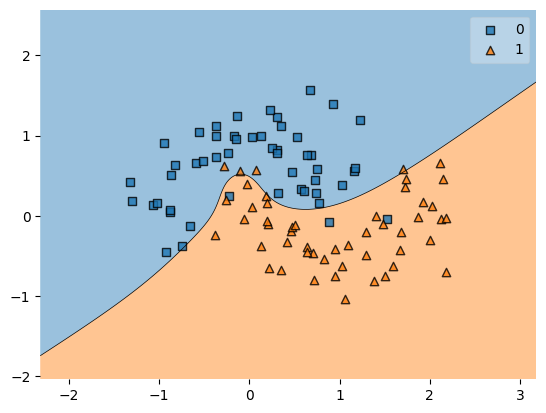

In [78]:
plot_decision_regions(x, y.astype(np.integer), clf=model10)

In [79]:
model11 = Sequential()
model11.add(Dense(10, activation='sigmoid', input_dim=2, kernel_initializer="he_uniform"))
model11.add(Dense(10, activation='sigmoid', kernel_initializer="he_uniform"))
model11.add(Dense(10, activation='sigmoid', kernel_initializer="he_uniform"))
model11.add(Dense(10, activation='sigmoid', kernel_initializer="he_uniform"))
model11.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
model11.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_65 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_66 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_67 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_68 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model11.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [82]:
history11 = model11.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.4883 - loss: 0.7021 - val_accuracy: 0.5000 - val_loss: 0.6968
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.6974 - val_accuracy: 0.5000 - val_loss: 0.6953
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4883 - loss: 0.6983 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5039 - loss: 0.6942 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 0.6941 - val_accuracy: 0.5000 - val_loss: 0.6920
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5039 - loss: 0.6924 - val_accuracy: 0.5000 - val_loss: 0.6913
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6909
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4961 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss

He_Uniform - Sigmoid

   1/9600 ━━━━━━━━━━━━━━━━━━━━ 18:12 114ms/step

<ipython-input-83-50911a72141c>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model11)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

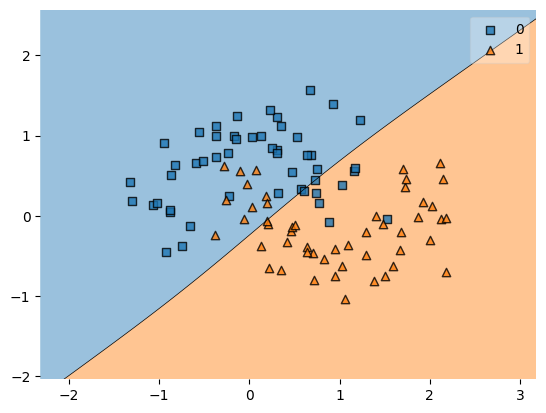

In [83]:
plot_decision_regions(x, y.astype(np.integer), clf=model11)

**He_Uniform - ReLU / TanH are best**

In [84]:
model12 = Sequential()
model12.add(Dense(10, activation='relu', input_dim=2, kernel_initializer="lecun_normal"))
model12.add(Dense(10, activation='relu', kernel_initializer="lecun_normal"))
model12.add(Dense(10, activation='relu', kernel_initializer="lecun_normal"))
model12.add(Dense(10, activation='relu', kernel_initializer="lecun_normal"))
model12.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [85]:
model12.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_70 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_71 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_72 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_73 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model12.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [87]:
history12 = model12.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step - accuracy: 0.4805 - loss: 0.6937 - val_accuracy: 0.5500 - val_loss: 0.6816
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5000 - loss: 0.6877 - val_accuracy: 0.5500 - val_loss: 0.6748
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5586 - loss: 0.6837 - val_accuracy: 0.7500 - val_loss: 0.6680
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6070 - loss: 0.6758 - val_accuracy: 0.8000 - val_loss: 0.6613
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7297 - loss: 0.6724 - val_accuracy: 0.8000 - val_loss: 0.6548
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7602 - loss: 0.6649 - val_accuracy: 0.8500 - val_loss: 0.6484
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7547 - loss: 0.6620 - val_accuracy: 0.8500 - val_loss: 0.6422
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7469 - loss: 0.6584 - val_accuracy: 0.8500 - val_loss

Lecun_Normal - ReLU

  46/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step   

<ipython-input-88-c1db2c30ad45>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model12)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

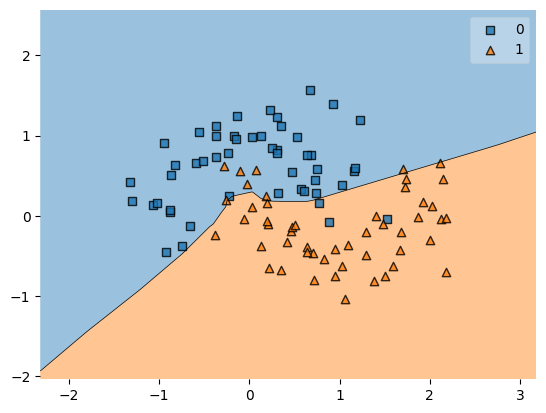

In [88]:
plot_decision_regions(x, y.astype(np.integer), clf=model12)

In [89]:
model13 = Sequential()
model13.add(Dense(10, activation='tanh', input_dim=2, kernel_initializer="lecun_normal"))
model13.add(Dense(10, activation='tanh', kernel_initializer="lecun_normal"))
model13.add(Dense(10, activation='tanh', kernel_initializer="lecun_normal"))
model13.add(Dense(10, activation='tanh', kernel_initializer="lecun_normal"))
model13.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [90]:
model13.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_74 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_75 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_76 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_77 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_78 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
model13.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [92]:
history13 = model13.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.7484 - loss: 0.6334 - val_accuracy: 0.8500 - val_loss: 0.5854
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8117 - loss: 0.6078 - val_accuracy: 0.8500 - val_loss: 0.5637
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7937 - loss: 0.5869 - val_accuracy: 0.8500 - val_loss: 0.5439
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7781 - loss: 0.5777 - val_accuracy: 0.8500 - val_loss: 0.5256
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7820 - loss: 0.5641 - val_accuracy: 0.8500 - val_loss: 0.5078
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7844 - loss: 0.5495 - val_accuracy: 0.8500 - val_loss: 0.4905
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8078 - loss: 0.5238 - val_accuracy: 0.8500 - val_loss: 0.4738
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7961 - loss: 0.5179 - val_accuracy: 0.8500 - val_loss

Lecun_Normal - TanH

  46/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step   

<ipython-input-94-42d5f6013bad>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model13)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


<Axes: >

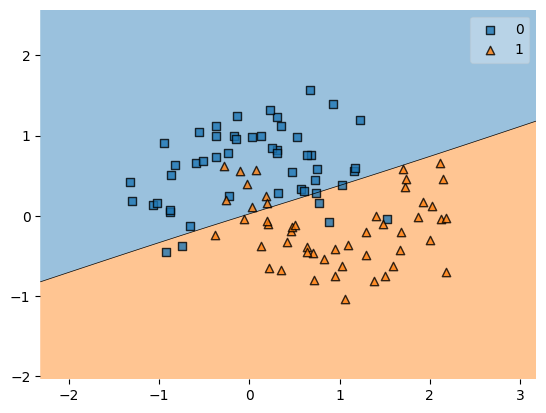

In [94]:
plot_decision_regions(x, y.astype(np.integer), clf=model13)

In [93]:
model14 = Sequential()
model14.add(Dense(10, activation='sigmoid', input_dim=2, kernel_initializer="lecun_normal"))
model14.add(Dense(10, activation='sigmoid', kernel_initializer="lecun_normal"))
model14.add(Dense(10, activation='sigmoid', kernel_initializer="lecun_normal"))
model14.add(Dense(10, activation='sigmoid', kernel_initializer="lecun_normal"))
model14.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [95]:
model14.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_79 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_80 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_81 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_82 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_83 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
model14.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [97]:
history14 = model14.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.5352 - loss: 0.6918 - val_accuracy: 0.5000 - val_loss: 0.6958
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5195 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6953
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4648 - loss: 0.6991 - val_accuracy: 0.5000 - val_loss: 0.6948
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5039 - loss: 0.6942 - val_accuracy: 0.5000 - val_loss: 0.6947
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4883 - loss: 0.6954 - val_accuracy: 0.5000 - val_loss: 0.6945
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4805 - loss: 0.6959 - val_accuracy: 0.5000 - val_loss: 0.6944
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4688 - loss: 0.6966 - val_accuracy: 0.5000 - val_loss: 0.6943
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4922 - loss: 0.6946 - val_accuracy: 0.5000 - val_loss

Lecun_Normal - Sigmoid

<ipython-input-98-2adf3e55e980>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model14)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

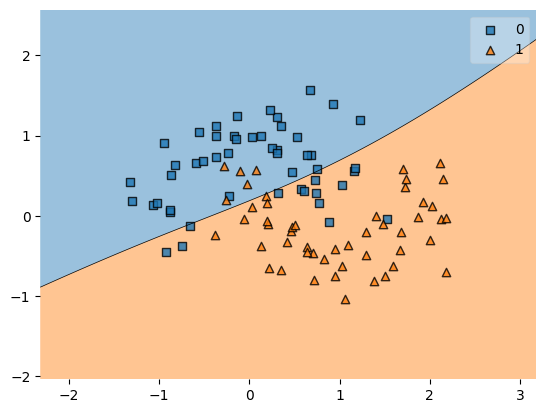

In [98]:
plot_decision_regions(x, y.astype(np.integer), clf=model14)

**Lecun Normal - ReLU is best**

In [99]:
model15 = Sequential()
model15.add(Dense(10, activation='relu', input_dim=2, kernel_initializer="lecun_uniform"))
model15.add(Dense(10, activation='relu', kernel_initializer="lecun_uniform"))
model15.add(Dense(10, activation='relu', kernel_initializer="lecun_uniform"))
model15.add(Dense(10, activation='relu', kernel_initializer="lecun_uniform"))
model15.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [100]:
model15.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_84 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_85 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_86 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_87 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_88 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
model15.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [102]:
history15 = model15.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.5117 - loss: 0.6765 - val_accuracy: 0.5000 - val_loss: 0.6718
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5016 - loss: 0.6684 - val_accuracy: 0.5000 - val_loss: 0.6675
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5016 - loss: 0.6697 - val_accuracy: 0.5000 - val_loss: 0.6629
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4914 - loss: 0.6581 - val_accuracy: 0.4500 - val_loss: 0.6583
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4977 - loss: 0.6511 - val_accuracy: 0.4500 - val_loss: 0.6537
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4820 - loss: 0.6571 - val_accuracy: 0.4500 - val_loss: 0.6490
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4805 - loss: 0.6576 - val_accuracy: 0.5000 - val_loss: 0.6441
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4844 - loss: 0.6524 - val_accuracy: 0.5000 - val_loss

Lecun Uniform - ReLU

<ipython-input-103-8b14eac68dfa>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model15)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


<Axes: >

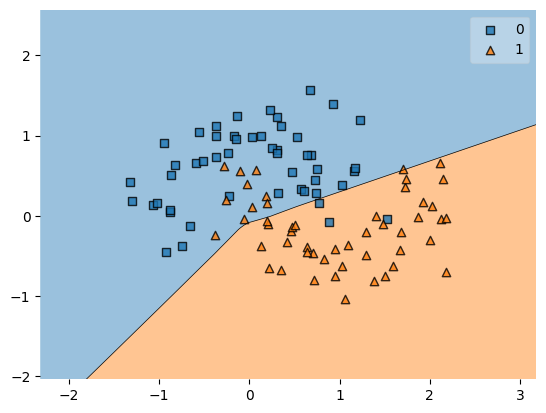

In [103]:
plot_decision_regions(x, y.astype(np.integer), clf=model15)

In [106]:
model16 = Sequential()
model16.add(Dense(10, activation='tanh', input_dim=2, kernel_initializer="lecun_uniform"))
model16.add(Dense(10, activation='tanh', kernel_initializer="lecun_uniform"))
model16.add(Dense(10, activation='tanh', kernel_initializer="lecun_uniform"))
model16.add(Dense(10, activation='tanh', kernel_initializer="lecun_uniform"))
model16.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [108]:
model16.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_91 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_92 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_93 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_94 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_95 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
model16.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [110]:
history16 = model16.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - accuracy: 0.6359 - loss: 0.6440 - val_accuracy: 0.6000 - val_loss: 0.6468
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6719 - loss: 0.6257 - val_accuracy: 0.7000 - val_loss: 0.6259
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7070 - loss: 0.5951 - val_accuracy: 0.7500 - val_loss: 0.6076
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7109 - loss: 0.5824 - val_accuracy: 0.8000 - val_loss: 0.5904
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6898 - loss: 0.5832 - val_accuracy: 0.8000 - val_loss: 0.5743
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7516 - loss: 0.5661 - val_accuracy: 0.8500 - val_loss: 0.5592
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7742 - loss: 0.5587 - val_accuracy: 0.8500 - val_loss: 0.5445
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7922 - loss: 0.5493 - val_accuracy: 0.9000 - val_loss

Lecun Uniform - TanH

<ipython-input-111-a6632e41fed3>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model16)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


<Axes: >

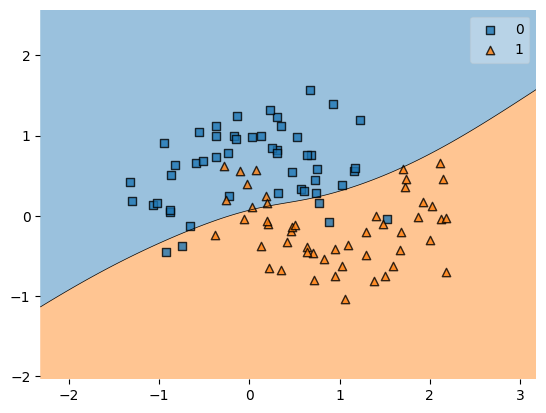

In [111]:
plot_decision_regions(x, y.astype(np.integer), clf=model16)

In [112]:
model17 = Sequential()
model17.add(Dense(10, activation='sigmoid', input_dim=2, kernel_initializer="lecun_uniform"))
model17.add(Dense(10, activation='sigmoid', kernel_initializer="lecun_uniform"))
model17.add(Dense(10, activation='sigmoid', kernel_initializer="lecun_uniform"))
model17.add(Dense(10, activation='sigmoid', kernel_initializer="lecun_uniform"))
model17.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [113]:
model17.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_96 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_97 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_98 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_99 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_100 (Dense)                    │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
model17.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [115]:
history17 = model17.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.5039 - loss: 0.7526 - val_accuracy: 0.5000 - val_loss: 0.7514
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5430 - loss: 0.7206 - val_accuracy: 0.5000 - val_loss: 0.7473
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5000 - loss: 0.7467 - val_accuracy: 0.5000 - val_loss: 0.7432
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4961 - loss: 0.7452 - val_accuracy: 0.5000 - val_loss: 0.7394
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4844 - loss: 0.7487 - val_accuracy: 0.5000 - val_loss: 0.7358
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4766 - loss: 0.7495 - val_accuracy: 0.5000 - val_loss: 0.7325
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4961 - loss: 0.7345 - val_accuracy: 0.5000 - val_loss: 0.7295
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5312 - loss: 0.7118 - val_accuracy: 0.5000 - val_loss

Lecun Uniform - Sigmoid

<ipython-input-116-e42b542af0bf>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model17)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

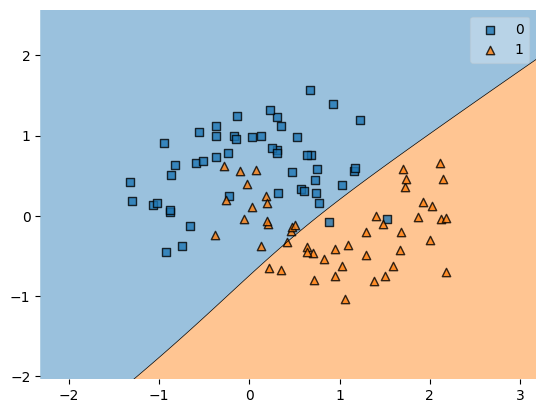

In [116]:
plot_decision_regions(x, y.astype(np.integer), clf=model17)

**Lecun Uniform - TanH is Best**

In [8]:
model18 = Sequential()
model18.add(Dense(10, activation='relu', input_dim=2, kernel_initializer="random_normal"))
model18.add(Dense(10, activation='relu', kernel_initializer="random_normal"))
model18.add(Dense(10, activation='relu', kernel_initializer="random_normal"))
model18.add(Dense(10, activation='relu', kernel_initializer="random_normal"))
model18.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model18.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model18.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
history18 = model18.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - accuracy: 0.4273 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4898 - loss: 0.6931 - val_accuracy: 0.8000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6656 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5039 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5078 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4961 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4844 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5141 - loss: 0.6928 - val_accuracy: 0.6500 - val_loss

Random Normal - ReLU

   1/9600 ━━━━━━━━━━━━━━━━━━━━ 21:26 134ms/step

<ipython-input-12-7b3c66aa6b3e>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model18)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: >

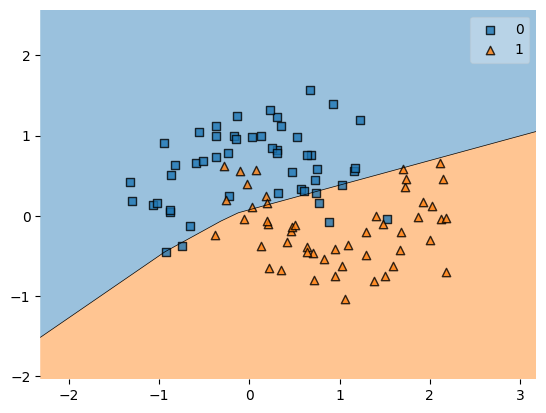

In [12]:
plot_decision_regions(x, y.astype(np.integer), clf=model18)

In [14]:
model19 = Sequential()
model19.add(Dense(10, activation='tanh', input_dim=2, kernel_initializer="random_normal"))
model19.add(Dense(10, activation='tanh', kernel_initializer="random_normal"))
model19.add(Dense(10, activation='tanh', kernel_initializer="random_normal"))
model19.add(Dense(10, activation='tanh', kernel_initializer="random_normal"))
model19.add(Dense(1, activation='sigmoid'))

In [15]:
model19.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model19.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [17]:
history19 = model19.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.2961 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5156 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5156 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4844 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5039 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5039 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5117 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5039 - loss: 0.6926 - val_accuracy: 0.5500 - val_loss

Random Normal - TanH

<ipython-input-18-ffdce73e53e7>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model19)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

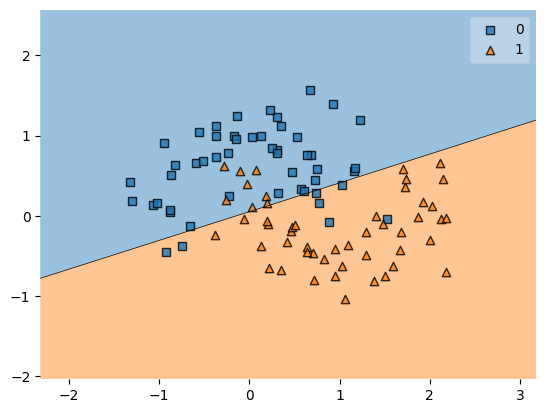

In [18]:
plot_decision_regions(x, y.astype(np.integer), clf=model19)

In [19]:
model20 = Sequential()
model20.add(Dense(10, activation='sigmoid', input_dim=2, kernel_initializer="random_normal"))
model20.add(Dense(10, activation='sigmoid', kernel_initializer="random_normal"))
model20.add(Dense(10, activation='sigmoid', kernel_initializer="random_normal"))
model20.add(Dense(10, activation='sigmoid', kernel_initializer="random_normal"))
model20.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model20.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model20.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [22]:
history20 = model20.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.5156 - loss: 0.7671 - val_accuracy: 0.5000 - val_loss: 0.7747
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4805 - loss: 0.7897 - val_accuracy: 0.5000 - val_loss: 0.7678
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4805 - loss: 0.7823 - val_accuracy: 0.5000 - val_loss: 0.7615
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4688 - loss: 0.7841 - val_accuracy: 0.5000 - val_loss: 0.7556
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5078 - loss: 0.7490 - val_accuracy: 0.5000 - val_loss: 0.7505
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5156 - loss: 0.7388 - val_accuracy: 0.5000 - val_loss: 0.7456
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5430 - loss: 0.7163 - val_accuracy: 0.5000 - val_loss: 0.7409
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4570 - loss: 0.7673 - val_accuracy: 0.5000 - val_loss

Random Normal - Sigmoid

  45/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step   

<ipython-input-23-6cec35663270>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model20)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

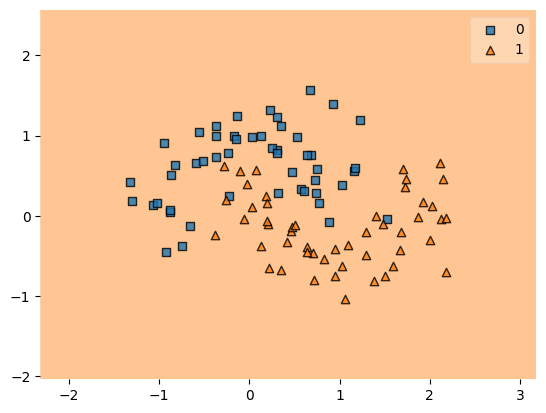

In [23]:
plot_decision_regions(x, y.astype(np.integer), clf=model20)

**Random Normal - ReLU is Best**

**TanH is okay just a little missclassification**

**Sigmoid not working at all**

In [24]:
model21 = Sequential()
model21.add(Dense(10, activation='relu', input_dim=2, kernel_initializer="random_uniform"))
model21.add(Dense(10, activation='relu', kernel_initializer="random_uniform"))
model21.add(Dense(10, activation='relu', kernel_initializer="random_uniform"))
model21.add(Dense(10, activation='relu', kernel_initializer="random_uniform"))
model21.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model21.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model21.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [27]:
history21 = model21.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.5078 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5156 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5039 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4234 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5234 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5117 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4883 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5430 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss

Random Uniform - ReLU

<ipython-input-28-eaf1ac8d748c>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model21)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

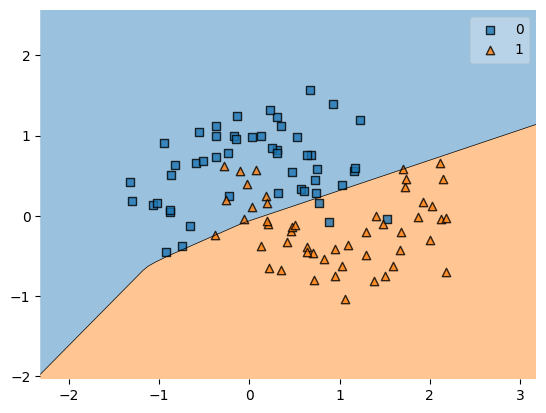

In [28]:
plot_decision_regions(x, y.astype(np.integer), clf=model21)

In [29]:
model22 = Sequential()
model22.add(Dense(10, activation='tanh', input_dim=2, kernel_initializer="random_uniform"))
model22.add(Dense(10, activation='tanh', kernel_initializer="random_uniform"))
model22.add(Dense(10, activation='tanh', kernel_initializer="random_uniform"))
model22.add(Dense(10, activation='tanh', kernel_initializer="random_uniform"))
model22.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model22.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model22.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [32]:
history22 = model22.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.5516 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4961 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5156 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5273 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5195 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5078 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5523 - loss: 0.6928 - val_accuracy: 0.8500 - val_loss

Random uniform - TanH

  42/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step   

<ipython-input-33-a84a589a467d>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model22)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

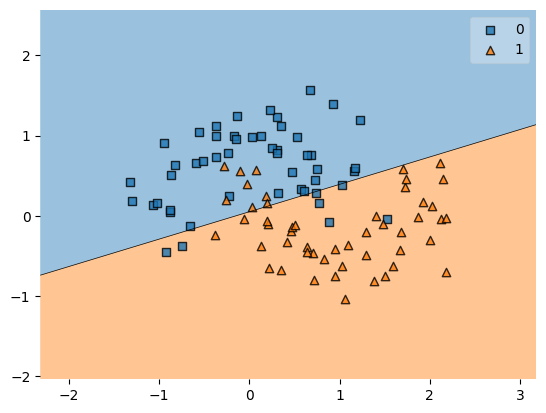

In [33]:
plot_decision_regions(x, y.astype(np.integer), clf=model22)

In [35]:
model23 = Sequential()
model23.add(Dense(10, activation='sigmoid', input_dim=2, kernel_initializer="random_uniform"))
model23.add(Dense(10, activation='sigmoid', kernel_initializer="random_uniform"))
model23.add(Dense(10, activation='sigmoid', kernel_initializer="random_uniform"))
model23.add(Dense(10, activation='sigmoid', kernel_initializer="random_uniform"))
model23.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model23.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model23.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [38]:
history23 = model23.fit(x, y, epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.5000 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4961 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4922 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4883 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.4570 - loss: 0.6941 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5312 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5156 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5352 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss

Random Uniform - Sigmoid

   1/9600 ━━━━━━━━━━━━━━━━━━━━ 14:01 88ms/step

<ipython-input-39-af49eeaf06e3>:1: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(x, y.astype(np.integer), clf=model23)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

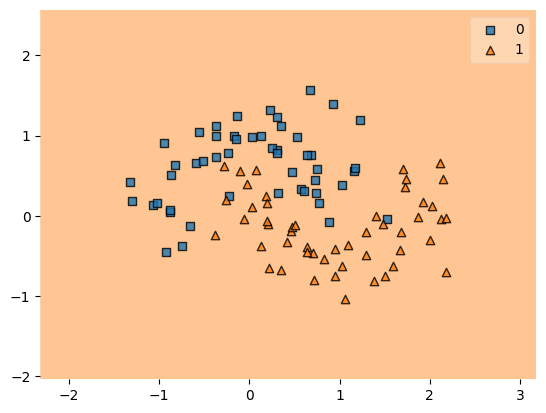

In [39]:
plot_decision_regions(x, y.astype(np.integer), clf=model23)

**Random Uniform - ReLU is Best**

**TanH is okay just a little missclassification**

**Sigmoid not working at all**